In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
import math
import re
from collections import Counter
import torch.nn.functional as F

/opt/miniconda3/envs/llm_training/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


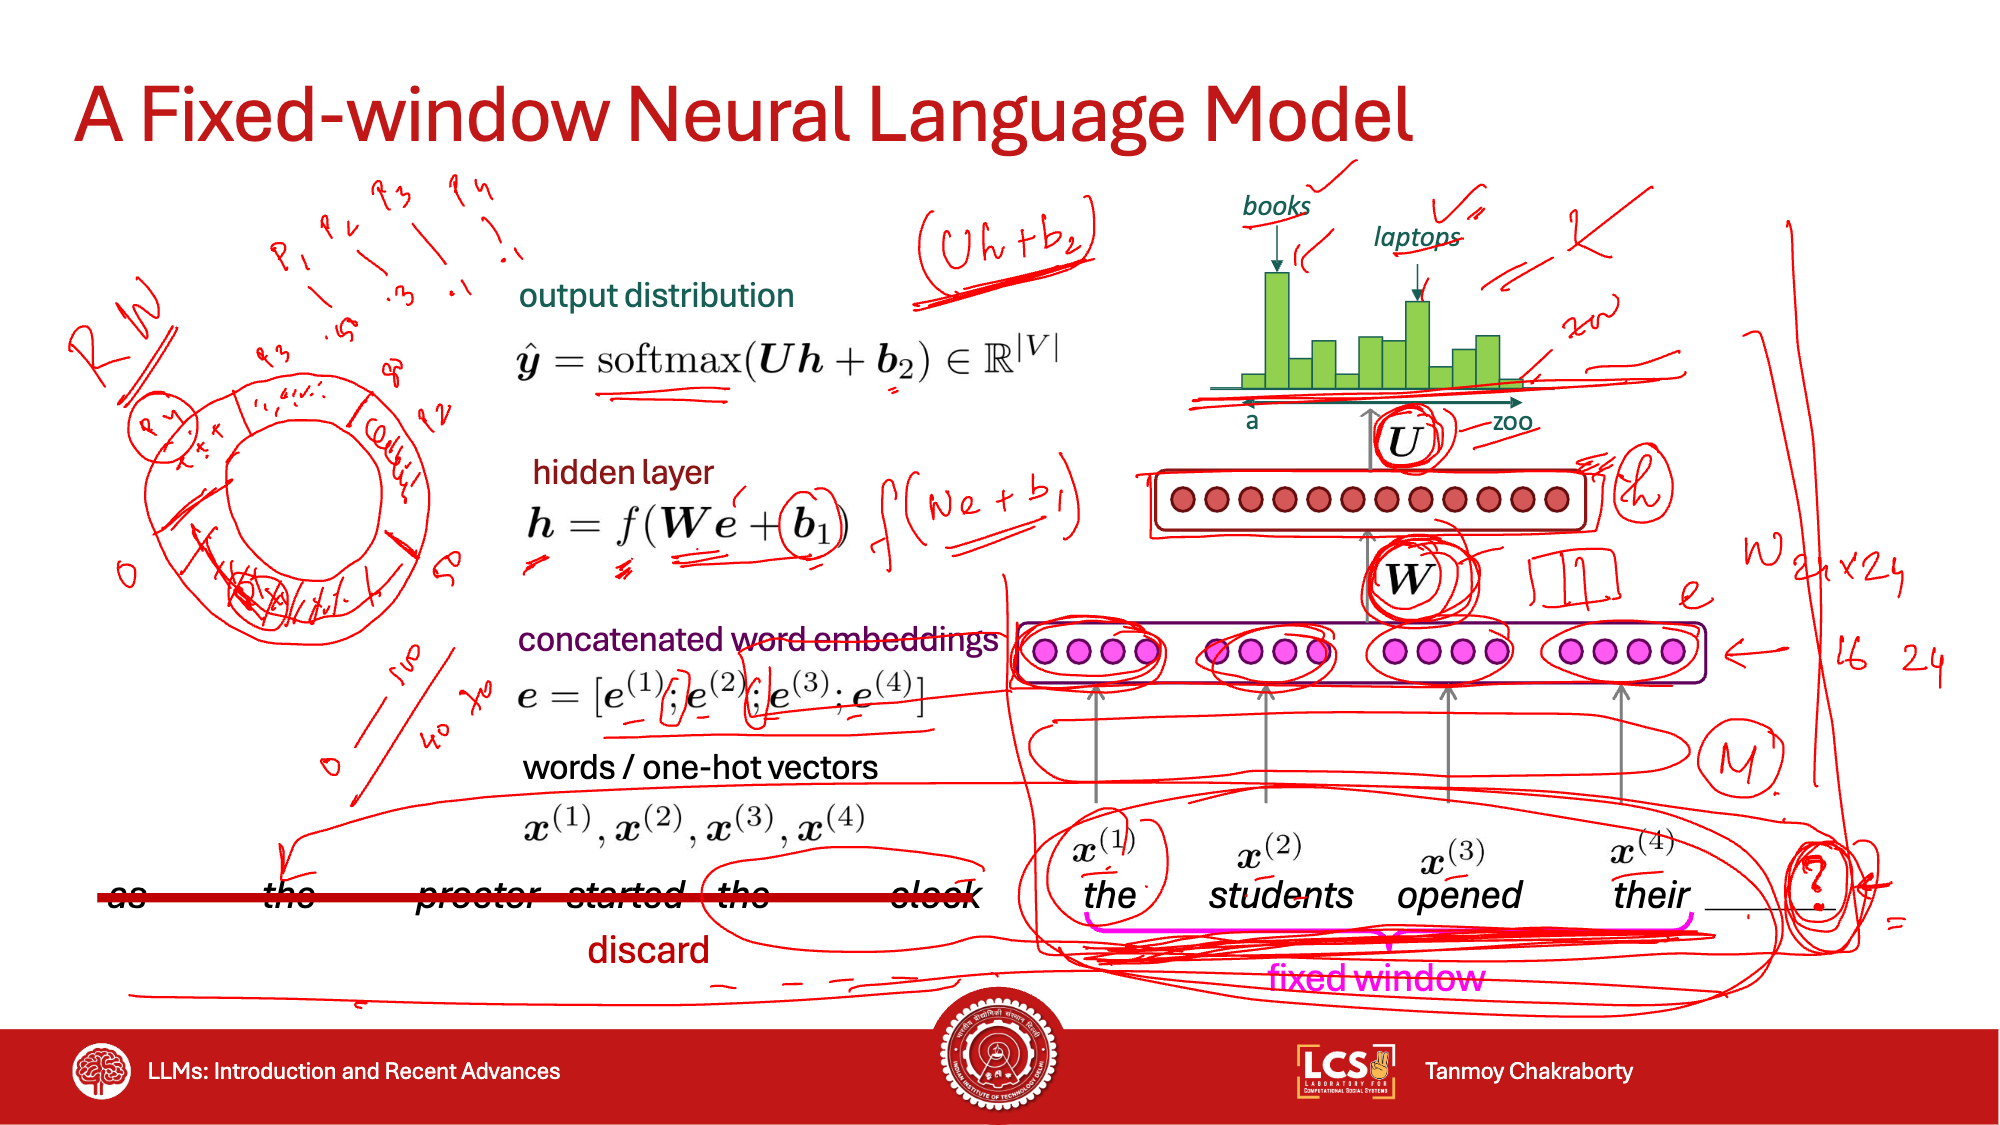

In [37]:
# ---- Hyperparameters ----
context_size = 5
embedding_dim = 100
hidden_dim = 128
batch_size = 128
epochs = 5
# if torch.backends.mps.is_available():
#     device = torch.device("mps")
# else:
device = torch.device("mps")

In [15]:
device

device(type='mps')

In [38]:
# ---- Tokenization and Vocab ----
def get_tokenizer():
    """Basic English tokenizer similar to torchtext's basic_english"""
    return lambda text: re.findall(r"\w+|[^\w\s]", text.lower())

def build_vocab_from_iterator(data_iter, specials=["<unk>"]):
    """Build vocabulary from token iterator"""
    counter = Counter()
    for tokens in data_iter:
        counter.update(tokens)
    vocab = {token: idx for idx, (token, _) in enumerate(counter.most_common())}
    # Add special tokens at the beginning
    for i, special in enumerate(specials):
        vocab[special] = len(vocab)
    return vocab

# Load PTB dataset
ptb = load_dataset('ptb_text_only',trust_remote_code=True)
tokenizer = get_tokenizer()

In [55]:
ptb

DatasetDict({
    train: Dataset({
        features: ['sentence'],
        num_rows: 42068
    })
    test: Dataset({
        features: ['sentence'],
        num_rows: 3761
    })
    validation: Dataset({
        features: ['sentence'],
        num_rows: 3370
    })
})

In [58]:
# Build vocabulary from training data
def yield_tokens(data):
    for example in data:
        yield tokenizer(example['sentence'])

train_data = ptb['train']
vocab = build_vocab_from_iterator(yield_tokens(train_data), specials=["<unk>"])
# Instead of setting default_index, we'll use vocab.get(token, vocab["<unk>"]) when looking up tokens

In [56]:
vocab

{'the': 0,
 '<': 1,
 'unk': 2,
 '>': 3,
 'n': 4,
 'of': 5,
 'to': 6,
 'a': 7,
 'in': 8,
 'and': 9,
 '.': 10,
 "'": 11,
 's': 12,
 'for': 13,
 'that': 14,
 '$': 15,
 'is': 16,
 'it': 17,
 'said': 18,
 '-': 19,
 'on': 20,
 'at': 21,
 'by': 22,
 'as': 23,
 'from': 24,
 'million': 25,
 'with': 26,
 'mr': 27,
 'was': 28,
 'be': 29,
 'are': 30,
 'its': 31,
 'he': 32,
 't': 33,
 'but': 34,
 'has': 35,
 'an': 36,
 'will': 37,
 'have': 38,
 'year': 39,
 'new': 40,
 'or': 41,
 'company': 42,
 'they': 43,
 'this': 44,
 'which': 45,
 'would': 46,
 'about': 47,
 'market': 48,
 'says': 49,
 'more': 50,
 'were': 51,
 'u': 52,
 'one': 53,
 'billion': 54,
 'his': 55,
 'had': 56,
 'their': 57,
 'up': 58,
 'stock': 59,
 'than': 60,
 'who': 61,
 'some': 62,
 'been': 63,
 'also': 64,
 'share': 65,
 'other': 66,
 'corp': 67,
 'not': 68,
 'we': 69,
 'inc': 70,
 '&': 71,
 'i': 72,
 'two': 73,
 'if': 74,
 'when': 75,
 'last': 76,
 'president': 77,
 'shares': 78,
 'out': 79,
 'years': 80,
 'all': 81,
 'first': 

In [61]:
# ---- Dataset Construction ----
def build_dataset(data, context_size):
    dataset = []
    for example in data:
        tokens = tokenizer(example['sentence'])
        ids = [vocab.get(token, vocab["<unk>"]) for token in tokens]
        for i in range(context_size, len(ids)):
            context = ids[i - context_size:i]
            target = ids[i]
            dataset.append((context, target))
    return dataset

In [62]:
class PTBWindowDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __getitem__(self, idx):
        context, target = self.data[idx]
        return torch.tensor(context), torch.tensor(target)

    def __len__(self):
        return len(self.data)


In [65]:
ptb['train']

Dataset({
    features: ['sentence'],
    num_rows: 42068
})

In [63]:
# ---- Load Datasets ----
train_data = build_dataset(ptb['train'], context_size)
valid_data = build_dataset(ptb['validation'], context_size)

train_loader = DataLoader(PTBWindowDataset(train_data), batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(PTBWindowDataset(valid_data), batch_size=batch_size)

In [66]:
train_loader

In [43]:
# ---- Model ----
class FixedWindowNNLM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_size, hidden_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear1 = nn.Linear(context_size * embedding_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, vocab_size)

    def forward(self, inputs):
        embeds = self.embeddings(inputs)  # (batch, context, embed)
        embeds = embeds.view(embeds.size(0), -1)
        out = F.relu(self.linear1(embeds))
        out = self.linear2(out)
        return out

In [44]:
# ---- Initialize ----
model = FixedWindowNNLM(len(vocab), embedding_dim, context_size, hidden_dim).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [45]:
# ---- Evaluation Function ----
def evaluate(model, data_loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for context_batch, target_batch in data_loader:
            context_batch = context_batch.to(device)
            target_batch = target_batch.to(device)
            output = model(context_batch)
            loss = loss_fn(output, target_batch)
            total_loss += loss.item() * context_batch.size(0)
    total_tokens = len(data_loader.dataset)
    avg_loss = total_loss / total_tokens
    ppl = math.exp(avg_loss)
    return avg_loss, ppl

In [46]:
# ---- Training Loop ----
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0
    for context_batch, target_batch in train_loader:
        context_batch = context_batch.to(device)
        target_batch = target_batch.to(device)

        optimizer.zero_grad()
        output = model(context_batch)
        loss = loss_fn(output, target_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * context_batch.size(0)

    train_tokens = len(train_loader.dataset)
    train_loss = total_loss / train_tokens
    train_ppl = math.exp(train_loss)

    val_loss, val_ppl = evaluate(model, valid_loader)

    print(f"Epoch {epoch}:")
    print(f"  Train Loss: {train_loss:.4f}, Perplexity: {train_ppl:.2f}")
    print(f"  Val   Loss: {val_loss:.4f}, Perplexity: {val_ppl:.2f}")

Epoch 1:
  Train Loss: 5.2253, Perplexity: 185.91
  Val   Loss: 4.9887, Perplexity: 146.75
Epoch 2:
  Train Loss: 4.6392, Perplexity: 103.46
  Val   Loss: 4.9962, Perplexity: 147.86
Epoch 3:
  Train Loss: 4.3823, Perplexity: 80.03
  Val   Loss: 5.1752, Perplexity: 176.83
Epoch 4:
  Train Loss: 4.2238, Perplexity: 68.29
  Val   Loss: 5.3779, Perplexity: 216.57
Epoch 5:
  Train Loss: 4.1159, Perplexity: 61.31
  Val   Loss: 5.5814, Perplexity: 265.45


In [67]:
model.embeddings.weight.data

tensor([[-0.5587,  0.5365,  0.7725,  ...,  0.4035,  0.5290,  0.5228],
        [-0.3948,  1.4467,  0.0908,  ...,  0.4763, -0.0064,  0.5992],
        [-0.0933,  0.2835, -0.1883,  ...,  0.1755, -0.6442,  0.5434],
        ...,
        [ 2.0428,  0.6156, -0.9095,  ...,  2.2646, -0.3031,  1.5621],
        [-1.7603, -0.1636,  0.2010,  ..., -2.1799,  1.1390,  1.6332],
        [ 0.2768, -0.9570, -0.0715,  ...,  0.2912,  0.6141,  0.0336]],
       device='mps:0')

In [48]:
# Create a reverse mapping from indices to tokens
idx_to_token = {idx: token for token, idx in vocab.items()}

# Update the predict_next_word function
def predict_next_word(model, context_words, vocab, idx_to_token, top_k=5, sample=False):
    model.eval()
    tokens = [vocab.get(word, vocab["<unk>"]) for word in context_words]
    
    # Ensure tensor shape is (1, context_size)
    context_tensor = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(context_tensor)  # shape: (1, vocab_size)
        probs = F.softmax(logits, dim=-1).squeeze()

        if sample:
            next_id = torch.multinomial(probs, 1).item()
        else:
            next_id = torch.topk(probs, 1).indices.item()
        
        return idx_to_token[next_id], [(idx_to_token[i.item()], probs[i].item()) for i in torch.topk(probs, top_k).indices]

context = ["the", "stock", "market","is", "going"]
next_word, top_preds = predict_next_word(model, context, vocab, idx_to_token, sample=True)

print(f"Context: {' '.join(context)}")
print(f"Next Word (sampled): {next_word}")
print("Top Predictions:")
for word, prob in top_preds:
    print(f"  {word:10} {prob:.4f}")

Context: the stock market is going
Next Word (sampled): to
Top Predictions:
  to         0.7415
  for        0.0249
  down       0.0244
  into       0.0169
  back       0.0160


In [54]:
context = ["I", "like","cars", "than", "bike"]
next_word, top_preds = predict_next_word(model, context, vocab, idx_to_token, sample=True)

print(f"Context: {' '.join(context)}")
print(f"Next Word (sampled): {next_word}")
print("Top Predictions:")
for word, prob in top_preds:
    print(f"  {word:10} {prob:.4f}")

Context: I like cars than bike
Next Word (sampled): anyone
Top Predictions:
  <          0.0692
  the        0.0292
  and        0.0231
  a          0.0174
  -          0.0155
